# The MBRA sub-Fermi volume depth: what does "$-8.400A$" mean?

Table I of [Morillon, Blanchon, Romain & Arellano, Phys. Rev. C **109**, 044611
(2024)](https://doi.org/10.1103/PhysRevC.109.044611) (arXiv:2403.05843) prints
the sub-Fermi depth of the local volume imaginary term (Eqs. 14–16) as

$$A_V^- \;=\; -8.400A \quad \text{for } E < E_F,$$

i.e. apparently *proportional to the target mass* $A$. This notebook shows that
the literal reading is inconsistent with the paper's own Fig. 3(b), which plots
$W_V^L(E)$ and its dispersive correction $\Delta V_V^L(E)$ for $^{40}$Ca,
$^{89}$Y and $^{208}$Pb, and identifies the reading adopted by
`jitr.optical_potentials.mbra`.

**Landmarks of Fig. 3(b)** (read off the published figure):

1. The panel's $y$-axis spans roughly $-20$ to $+10$ MeV — every curve stays
   inside it at all energies.
2. Below the Fermi energy, $W_V^L$ has a shallow dip of about $-2.5$ to
   $-3$ MeV near $E \approx -55$ MeV, then returns to zero at large negative
   $E$ (the Eq. 16 suppression).
3. The three nuclei are **nearly degenerate** below $E_F$ — the dashed
   ($^{40}$Ca), solid ($^{89}$Y) and dotted ($^{208}$Pb) curves are almost
   indistinguishable there, in sharp contrast to the $E > E_F$ side where
   $A_V^+ = -32.40 - 2.000\times10^{-2}A$ separates them visibly.

Any candidate reading of "$-8.400A$" must reproduce all three. We test four:

| reading | $A_V^-$ for $^{40}$Ca / $^{89}$Y / $^{208}$Pb |
|---|---|
| literal $-8.400\cdot A$ | $-336$ / $-748$ / $-1747$ MeV |
| constant $-8.400$ (stray "$A$") | $-8.4$ MeV |
| $-8.400\cdot A^{1/3}$ (misprinted root) | $-28.7$ / $-37.5$ / $-49.8$ MeV |
| constant $-48.40$ (dropped digit; `jitr` default) | $-48.4$ MeV |


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

import jitr
from jitr.optical_potentials import mbra

In [2]:
neutron = (1, 0)
# (A, Z) and the paper's line style for the three nuclei of Fig. 3
cases = [((40, 20), "dashed"), ((89, 39), "solid"), ((208, 82), "dotted")]

readings = {
    r"literal $-8.400\,A$": lambda A: -8.400 * A,
    r"constant $-8.400$": lambda A: -8.400,
    r"$-8.400\,A^{1/3}$": lambda A: -8.400 * A ** (1.0 / 3.0),
    r"constant $-48.40$ (jitr default)": lambda A: -48.40,
}

E = np.linspace(-249.0, 249.0, 999)
curves = {}  # (reading, A) -> dict(Ef, AVm, W, dV)
for (A, Z), _ in cases:
    rxn = jitr.reactions.Reaction(target=(A, Z), projectile=neutron, process="EL")
    c = mbra.resolve_coefficients(A)
    for name, read in readings.items():
        AVm = read(A)
        args = (rxn.Ef, c.AV_plus, AVm, c.BV, c.EV_plus, c.EV_minus, c.ALPHA)
        curves[name, A] = dict(
            Ef=rxn.Ef,
            AVm=AVm,
            W=mbra.Wv_depth(E, *args),
            dV=mbra.delta_Vv_depth(E, *args),
        )

## $W_V^L$ and $\Delta V_V^L$ under each reading

One panel per reading, drawn on the axes of Fig. 3(b) ($E \in [-250, 250]$ MeV,
depths from $-20$ to $+10$ MeV) with the paper's conventions: red for
$W_V^L$, blue for $\Delta V_V^L$, dashed/solid/dotted for
$^{40}$Ca/$^{89}$Y/$^{208}$Pb. The gray band marks the eyeballed sub-Fermi dip
of the published figure ($-2.5$ to $-3.2$ MeV near $E \approx -55$ MeV).

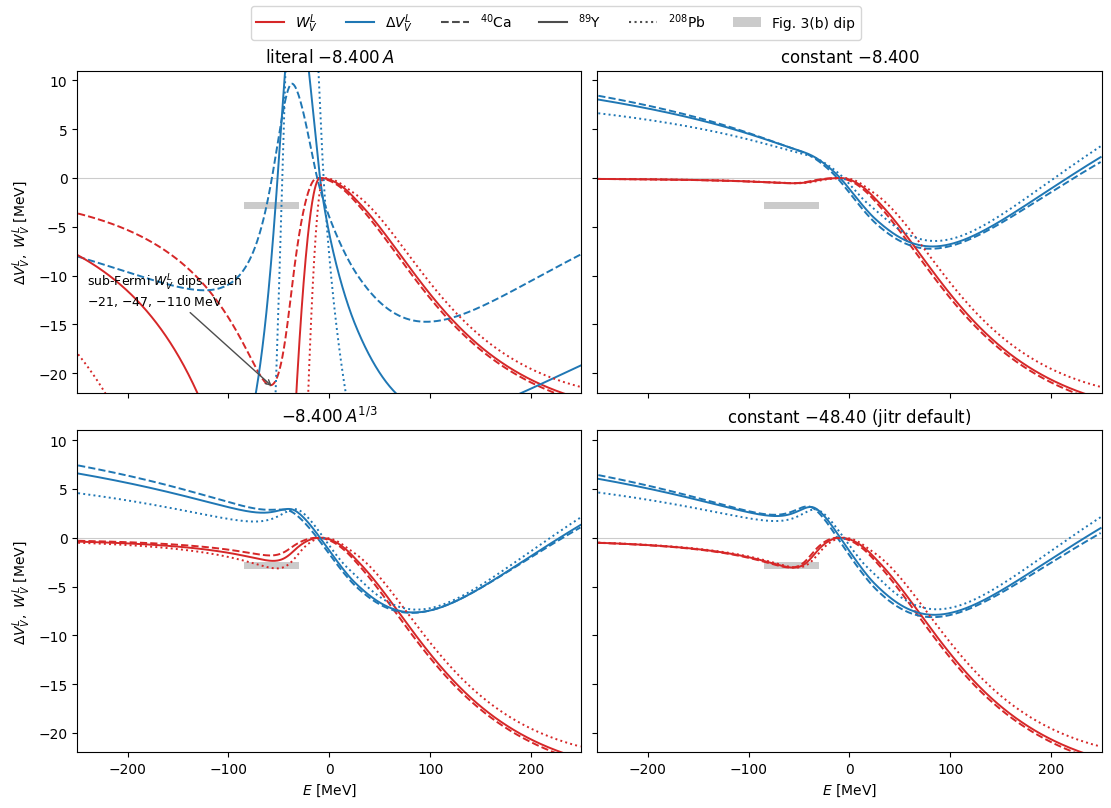

In [3]:
fig, axes = plt.subplots(
    2, 2, figsize=(11, 8), sharex=True, sharey=True, constrained_layout=True
)
for ax, name in zip(axes.flat, readings, strict=True):
    for (A, _), style in cases:
        d = curves[name, A]
        ax.plot(E, d["W"], color="tab:red", ls=style, lw=1.4)
        ax.plot(E, d["dV"], color="tab:blue", ls=style, lw=1.4)
    ax.fill_between([-85.0, -30.0], -3.2, -2.5, color="0.55", alpha=0.45, lw=0)
    ax.axhline(0.0, color="0.8", lw=0.8, zorder=0)
    ax.set_title(name)
    ax.set_xlim(-250.0, 250.0)
    ax.set_ylim(-22.0, 11.0)
    # note sub-Fermi dips that leave the Fig. 3(b) window
    dips = [
        np.min(curves[name, A]["W"][E < curves[name, A]["Ef"]])
        for (A, _), _ in cases
    ]
    if min(dips) < -22.0:
        ax.annotate(
            "sub-Fermi $W_V^L$ dips reach\n"
            + ", ".join(f"${d:.0f}$" for d in dips)
            + " MeV",
            xy=(-55.0, -21.5),
            xytext=(-240.0, -13.0),
            fontsize=9,
            arrowprops=dict(arrowstyle="->", color="0.3"),
        )

for ax in axes[-1]:
    ax.set_xlabel(r"$E$ [MeV]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\Delta V_V^L,\ W_V^L$ [MeV]")

legend = [
    Line2D([], [], color="tab:red", label=r"$W_V^L$"),
    Line2D([], [], color="tab:blue", label=r"$\Delta V_V^L$"),
    Line2D([], [], color="0.3", ls="dashed", label=r"$^{40}$Ca"),
    Line2D([], [], color="0.3", ls="solid", label=r"$^{89}$Y"),
    Line2D([], [], color="0.3", ls="dotted", label=r"$^{208}$Pb"),
    plt.Rectangle((0, 0), 1, 1, fc="0.55", alpha=0.45, label="Fig. 3(b) dip"),
]
fig.legend(handles=legend, loc="outside upper center", ncols=6);

In [4]:
print(
    f"{'reading':<34}{'A':>5}{'A_V^- [MeV]':>13}"
    f"{'W dip [MeV]':>13}{'at E [MeV]':>12}{'max |dV| [MeV]':>16}"
)
for name in readings:
    for (A, _), _ in cases:
        d = curves[name, A]
        sub = E < d["Ef"]
        i = np.argmin(d["W"][sub])
        label = name.replace("$", "").replace("\\,", " ")
        print(
            f"{label:<34}{A:>5}{d['AVm']:>13.2f}"
            f"{d['W'][sub][i]:>13.2f}{E[sub][i]:>12.1f}"
            f"{np.max(np.abs(d['dV'])):>16.2f}"
        )

reading                               A  A_V^- [MeV]  W dip [MeV]  at E [MeV]  max |dV| [MeV]
literal -8.400 A                     40      -336.00       -21.23       -58.4           14.73
literal -8.400 A                     89      -747.60       -47.24       -55.9           33.26
literal -8.400 A                    208     -1747.20      -110.42       -51.9           86.97
constant -8.400                      40        -8.40        -0.53       -58.4            8.43
constant -8.400                      89        -8.40        -0.53       -55.9            8.04
constant -8.400                     208        -8.40        -0.53       -51.9            6.64
-8.400 A^{1/3}                       40       -28.73        -1.82       -58.4            7.70
-8.400 A^{1/3}                       89       -37.50        -2.37       -55.9            7.66
-8.400 A^{1/3}                      208       -49.77        -3.15       -51.9            7.36
constant -48.40 (jitr default)       40       -48.40        

## Verdict

- **Literal $-8.400\cdot A$ is untenable.** The sub-Fermi dip reaches $-21$,
  $-47$ and $-110$ MeV for Ca, Y and Pb — an order of magnitude below the
  $\pm 10$ MeV scale of Fig. 3(b), with a huge mass spread where the figure
  shows none. It also contaminates the *scattering region*: through the
  dispersion relation it drags $\Delta V_V^L(10\,\mathrm{MeV})$ to
  $\approx -18$ MeV for $^{208}$Pb, a real-volume shift that would destroy
  the paper's own cross-section fits (Figs. 5–6).
- **Constant $-8.400$** gives a dip of only $-0.5$ MeV — too shallow by a
  factor of $\sim\!6$.
- **$-8.400\cdot A^{1/3}$** lands close for $^{208}$Pb ($-49.8$ MeV) but
  produces a visible mass spread ($-1.8$ vs $-3.2$ MeV dips) that the
  near-degenerate curves of Fig. 3(b) rule out.
- **Constant $-48.40$ MeV** reproduces the figure: a $-3.06$ MeV dip at
  $E \approx -55$ MeV, identical for all three nuclei, and
  $|\Delta V_V^L| \lesssim 8$ MeV everywhere. This is the `jitr` default
  (`av_minus_0 = -48.40`, `av_minus_A = 0`).

A plausible provenance for the misprint is a dropped digit —
"$-48.400$" $\to$ "$-8.400$" — with the "$A$" being the *condition column*
("for $E < E_F$" is typeset in the same cell) or a stray from the
$A$-dependent $A_V^+$ row above it. The near-coincidence
$-8.400 \cdot 208^{1/3} = -49.8 \approx -48.4$ is suggestive but, as shown
above, the $A^{1/3}$ scaling itself contradicts the figure.

The parametrization keeps both degrees of freedom, so any other reading
remains representable by overriding `av_minus_0` / `av_minus_A` in the
parameter vector:

In [5]:
literal = mbra.resolve_coefficients(208, *mbra.TABLE_I_LITERAL_PARAMS)
default = mbra.resolve_coefficients(208)
print(f"literal reading (mbra.TABLE_I_LITERAL_PARAMS): A_V^-(208Pb) = {literal.AV_minus:9.2f} MeV")
print(f"jitr default    (mbra.get_default_params()):   A_V^-(208Pb) = {default.AV_minus:9.2f} MeV")

literal reading (mbra.TABLE_I_LITERAL_PARAMS): A_V^-(208Pb) =  -1747.20 MeV
jitr default    (mbra.get_default_params()):   A_V^-(208Pb) =    -48.40 MeV


## Update: lab-frame evaluation and the $-8.400\,A^{1/3}$ reading

Two candidate resolutions were investigated after this notebook was first
written; **neither fixes the discrepancies**:

1. **Energy frame.** `mbra.calculate_params` now takes the laboratory-frame
   energy (matching the kduq/wlh/chuq convention), but the frame choice
   *cannot* affect any comparison with Fig. 3: the figure plots the depth
   functions against $E$ directly, so the frame only shifts where observables
   sample them ($\sim$6% of the argument for $A=16$, 0.5% for $^{208}$Pb).
2. **$A_V^- = -8.400\,A^{1/3}$.** For $^{208}$Pb this equals $-49.8$ MeV
   $\approx -48.4$, so the Pb curves are numerically unchanged
   ($\Delta V_V^L$ moves by $<0.07$ MeV) and the $\Delta V_V^L$ deviation
   from Fig. 3(b) outside $0 < E < 100$ MeV persists; for $^{40}$Ca it
   shifts $\Delta V_V^L$ by only $\sim$1 MeV while introducing the
   1.3 MeV sub-Fermi $W_V^L$ mass spread (dips $-1.8/-2.4/-3.2$ MeV) that
   the near-degenerate published curves rule out.

The remaining ambiguities therefore require clarification from the authors.

## Draft note to the authors

> **Subject:** Questions on the NLD nonlocal dispersive OMP parametrization
> (Phys. Rev. C 109, 044611)
>
> Dear Dr. Morillon and co-authors,
>
> We have implemented your global nonlocal dispersive neutron optical model
> (Phys. Rev. C **109**, 044611) in the open-source scattering code
> [jitr](https://github.com/beykyle/jitr) and validated it against the
> figures and cross sections of the paper. A few parametrization details we
> could not resolve from the text; we would be grateful for clarification.
>
> 1. **Sub-Fermi volume depth $A_V^-$.** Table I prints "$-8.400A$ for
>    $E < E_F$". Read literally this gives $W_V^L$ dips of $-21$/$-47$/$-110$
>    MeV for $^{40}$Ca/$^{89}$Y/$^{208}$Pb — far outside the scale of your
>    Fig. 3(b). A *constant* $A_V^- = -48.40$ MeV instead reproduces panel
>    (b) precisely (a mass-independent $-3.1$ MeV dip near $E \approx -55$
>    MeV). Could you confirm the fitted value and form? (We also considered
>    $-8.400\,A^{1/3}$, which matches for Pb but introduces a mass spread
>    the figure does not show.)
>
> 2. **Dispersive partner of the Mahaux-Sartor tail.** Dispersing Eqs. 14-16
>    exactly (once-subtracted PV integral; the $\alpha\sqrt{E}$ tail via the
>    ECIS-06 closed form `dlpe`) reproduces Fig. 3(b)'s $\Delta V_V^L$ for
>    $0 < E < 100$ MeV but deviates by 2-3 MeV outside that window (e.g.
>    $+0.7$ vs $-1.7$ MeV at $E = 245$ MeV for $^{89}$Y; below $-100$ MeV
>    the figure instead matches a Brown-Rho-only dispersion). What
>    prescription generated the published $\Delta V_V^L$ curve?
>
> 3. **Energy frame.** Is the energy variable $E$ in Eqs. 13-17 the
>    laboratory or center-of-mass energy?
>
> 4. **Spin-orbit scale.** What numerical value of $(\hbar/m_\pi c)^2$ does
>    your code use (2.0 fm² vs the isospin-averaged 2.04 fm²)?
>
> 5. **Fermi energy.** Section III C prints
>    $E_F = -[S_n(Z,N) - S_n(Z,N+1)]/2$; the Fig. 3 dip positions suggest
>    the sum-average $-[S_n(Z,N) + S_n(Z,N+1)]/2$. Is the printed difference
>    a typo?
>
> 6. **Parity of $\Delta V_{so}$.** Fig. 3(c) shows $\Delta V_{so}$ even in
>    $E - E_F$ (as in VanderKam et al.), while the causal once-subtracted
>    dispersion of Eq. 17 is odd. Is the even form intended?
>
> The figure above (four readings of $A_V^-$ against Fig. 3(b)) summarizes
> point 1 and is available on request, as is our implementation.
>
> Thank you for an interesting paper, and for any light you can shed on
> these details.
>
> Best regards,
> *[your name]*